# max_parallel_workers_per_gather sweep — parallelism, on tpch

This notebook is a sibling of `sharedBuffers.ipynb`. It analyses the
**`logs/max_parallel_workers/`** sweep on the server: the same tpch workload
(pg 18.4) run at several caps (`mpw_2`, `mpw_4`, `mpw_6`), each on the **base**
schema and the **indexed** schema (`_idx`).

The GUC the benchmark script actually varies here is
**`max_parallel_workers_per_gather`** — the per-`Gather` worker cap — while
`max_worker_processes` (8) and `parallel_leader_participation` (on) stay at their
defaults. (The server folder is named `max_parallel_workers`; the values inside
are the per-gather cap.) It trades wall-clock time against concurrent power draw.
Its values are **worker counts**, so the x-axis is linear. A cohort here is
`(max_parallel_workers_per_gather | index_status)`.

## 1. Fetch the max_parallel_workers logs → local `mpw_cache/`

Walks `logs/max_parallel_workers/mpw_*/`, downloads every `query_timing_*` /
`query_samples_*` pair (base and `_idx`), and mirrors them into a **new** local
cache folder `mpw_cache/`. On a failed fetch it falls back to that cache.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_DIR = "/home/user01/GreenSQL/logs/max_parallel_workers"
CACHE_DIR = Path("mpw_cache")        # dedicated cache for this sweep
RETRIES = 5

PARAM_NAME = "max_parallel_workers_per_gather"
X_KIND = "count"                  # "mem" -> log2 x-axis; "count" -> linear

# file suffix -> index status
VARIANTS = {"tpch": "base", "tpch_idx": "idx"}

def p_to_val(name):
    m = re.match(r"mpw_(\d+)$", str(name))
    return int(m.group(1)) if m else None


def p_label(v):
    return str(int(v))

def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    for d in sftp.listdir(REMOTE_DIR):
                        if p_to_val(d) is None:
                            continue
                        dd = f"{REMOTE_DIR}/{d}"
                        try:
                            here = set(sftp.listdir(dd))
                        except IOError:
                            continue
                        for suf in VARIANTS:
                            for kind in ("timing", "samples"):
                                fn = f"query_{kind}_{suf}.csv"
                                if fn in here:
                                    blobs[f"{d}/{fn}"] = sftp.open(f"{dd}/{fn}").read()
                    if not blobs:
                        raise RuntimeError(f"no CSVs under {REMOTE_DIR}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        for rel, b in blobs.items():
            p = CACHE_DIR / rel
            p.parent.mkdir(parents=True, exist_ok=True)
            p.write_bytes(b)
        print(f"Fetched {PARAM_NAME} logs from {SSH_HOST}; cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*.csv")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
vals = sorted({p_to_val(rel.split('/')[0]) for rel in BLOBS})
print(f"source: {SOURCE};  {len(BLOBS)} files;  "
      f"{PARAM_NAME} values: {[p_label(v) for v in vals]}")

Fetched max_parallel_workers_per_gather logs from 192.168.1.42; cache 'mpw_cache/' updated.
source: server;  16 files;  max_parallel_workers_per_gather values: ['0', '2', '4', '6']


## 2. Build per-query data, keyed by `(max_parallel_workers_per_gather, index)`

Each directory is one **cohort**. Timing is reduced per-execution like
`sharedBuffers`; the samples file adds **`workers_launched`**, the counter this
sweep lives on, plus the planning/execution split.

In [2]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


parts_t, parts_s = [], []
for rel, b in BLOBS.items():
    dname, fn = rel.split("/", 1)
    val = p_to_val(dname)
    idx = "idx" if "_idx" in fn else "base"
    df = pd.read_csv(io.BytesIO(b))
    df["pval"] = val
    df["plabel"] = p_label(val)
    df["index_status"] = idx
    df["cohort"] = df["plabel"] + " | " + idx
    (parts_t if "timing" in fn else parts_s).append(df)

timing = pd.concat(parts_t, ignore_index=True)
samples = pd.concat(parts_s, ignore_index=True)
KEY = ["cohort", "query"]

# ---- timing -> per-execution (mean of measured batches, like testPlot) ----
mt = timing[timing["phase"] == "measured"].copy()
for c in ["batchnum", "elapsed_sec", "avg_copy_elapsed_sec", "server_sum_ms",
          "client_overhead_sec", "rapl_pkg_j", "rapl_core_j", "failed"]:
    mt[c] = pd.to_numeric(mt[c], errors="coerce")
mt = mt[mt["failed"].fillna(0) == 0]
bn = mt["batchnum"].replace(0, np.nan)
mt["copy_time"] = mt["avg_copy_elapsed_sec"]
mt["copy_pkg"] = mt["rapl_pkg_j"] / bn
mt["copy_core"] = mt["rapl_core_j"] / bn
mt["copy_overhead"] = mt["client_overhead_sec"] / bn
mt["copy_server"] = (mt["server_sum_ms"] / 1000.0) / bn
for c in ["copy_pkg", "copy_core"]:            # RAPL overflow -> N/A
    mt[c] = mt[c].mask(mt[c] < 0)

tim = mt.groupby(KEY, as_index=False).agg(
    n_batches=("batch_index", "size"),
    avg_time_s=("copy_time", "mean"), time_std=("copy_time", "std"),
    time_min=("copy_time", "min"), time_max=("copy_time", "max"),
    avg_pkg_j=("copy_pkg", "mean"), pkg_j_std=("copy_pkg", "std"),
    avg_core_j=("copy_core", "mean"), core_j_std=("copy_core", "std"),
    server_s=("copy_server", "mean"), overhead_s=("copy_overhead", "mean"),
    pval=("pval", "first"), plabel=("plabel", "first"),
    index_status=("index_status", "first"),
)
tim["time_mean"] = tim["avg_time_s"]
tim["sql_file"] = tim["query"].astype(str).str.split("/").str[-1]
tim["group"] = tim["query"].map(query_group)
tim["qid"] = tim["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)

# ---- samples -> server split + buffer / spill / parallelism counters ----
meas = samples[samples["phase"] == "measured"].copy()
for c in ["server_planning_ms", "server_execution_ms", "shared_hit_blks",
          "shared_read_blks", "temp_read_blks", "temp_written_blks",
          "rows_processed", "bytes_processed", "workers_launched",
          "plan_nodes", "scan_nodes", "rows_removed_filter"]:
    if c in meas.columns:
        meas[c] = pd.to_numeric(meas[c], errors="coerce")
agg = dict(
    plan_ms=("server_planning_ms", "mean"), exec_ms=("server_execution_ms", "mean"),
    shared_hit=("shared_hit_blks", "mean"), shared_read=("shared_read_blks", "mean"),
    temp_read=("temp_read_blks", "mean"), temp_written=("temp_written_blks", "mean"),
    rows_processed=("rows_processed", "mean"),
    bytes_processed=("bytes_processed", "mean"),
)
for name, col in (("workers", "workers_launched"), ("plan_nodes", "plan_nodes"),
                  ("scan_nodes", "scan_nodes"), ("rows_removed", "rows_removed_filter")):
    if col in meas.columns:
        agg[name] = (col, "mean")
smp = meas.groupby(KEY).agg(**agg)
smp["plan_ratio"] = smp["plan_ms"] / (smp["plan_ms"] + smp["exec_ms"]).replace(0, np.nan)
blks = (smp["shared_hit"] + smp["shared_read"]).replace(0, np.nan)
smp["cache_hit_pct"] = 100 * smp["shared_hit"] / blks
smp["read_mb"] = smp["shared_read"] * 8 / 1024.0        # 8 KB blocks -> MB
smp["temp_blks"] = smp["temp_read"] + smp["temp_written"]
smp["temp_mb"] = smp["temp_blks"] * 8 / 1024.0

data = tim.merge(smp.reset_index(), on=KEY, how="left")
r = data["plan_ratio"].fillna(0.0)
data["plan_s"] = data["server_s"] * r
data["exec_s"] = data["server_s"] * (1.0 - r)
data["cv_pct"] = 100 * data["time_std"] / data["avg_time_s"]
data["power_w"] = data["avg_pkg_j"] / data["avg_time_s"]
data["label"] = data["sql_file"]

PVALS = sorted(data["pval"].dropna().unique())
IDX_ALL = [s for s in ["base", "idx"] if s in set(data["index_status"])]
colours = {"base": "#4c72b0", "idx": "#dd8452"}


def set_xaxis(ax):
    if X_KIND == "mem":
        ax.set_xscale("log", base=2)
    ax.set_xticks(PVALS)
    ax.set_xticklabels([p_label(v) for v in PVALS])
    ax.set_xlabel(PARAM_NAME)


print(f"{len(data)} (cohort, query) rows; {data['qid'].nunique()} queries; "
      f"{data['group'].nunique()} query folders")
print(f"{PARAM_NAME}: {[p_label(v) for v in PVALS]}; index: {IDX_ALL}")
print(data.groupby(['plabel', 'index_status']).agg(
    queries=('qid', 'nunique'),
    total_runtime_s=('avg_time_s', 'sum'),
    total_energy_j=('avg_pkg_j', 'sum')).round(2).to_string())

424 (cohort, query) rows; 53 queries; 21 query folders
max_parallel_workers_per_gather: ['0', '2', '4', '6']; index: ['base', 'idx']
                     queries  total_runtime_s  total_energy_j
plabel index_status                                          
0      base               53           164.75         1752.35
       idx                53            54.68          536.71
2      base               53           150.18         1732.11
       idx                53            39.25          657.56
4      base               53           149.91         1752.67
       idx                53            39.33          685.96
6      base               53           150.07         1765.33
       idx                53            39.53          686.26


## 3. Main per-query plots, one figure per tpch query folder

Same layout as `sharedBuffers` §3. Each bar is
`variant [max_parallel_workers_per_gather | index]`; **indexed** bars are hatched
(`xx`); bars are ordered by the per-gather cap. Figures are split into runtime bins.

21 query folder(s) -> 22 figures


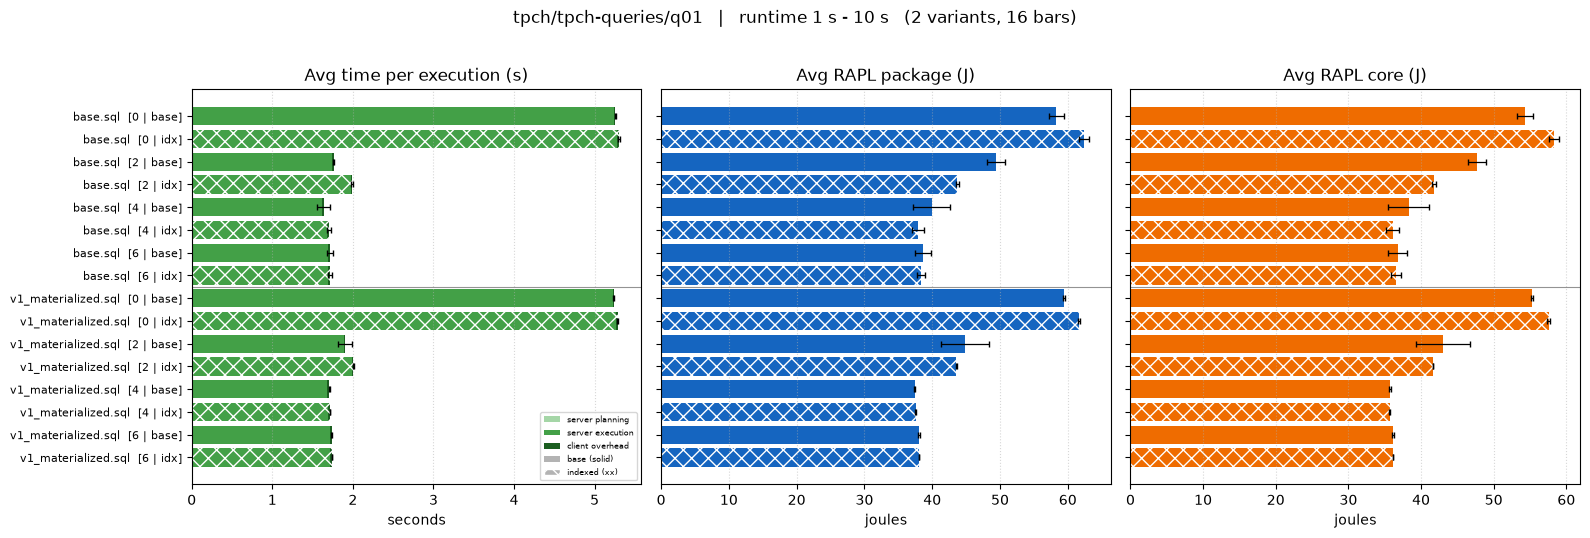

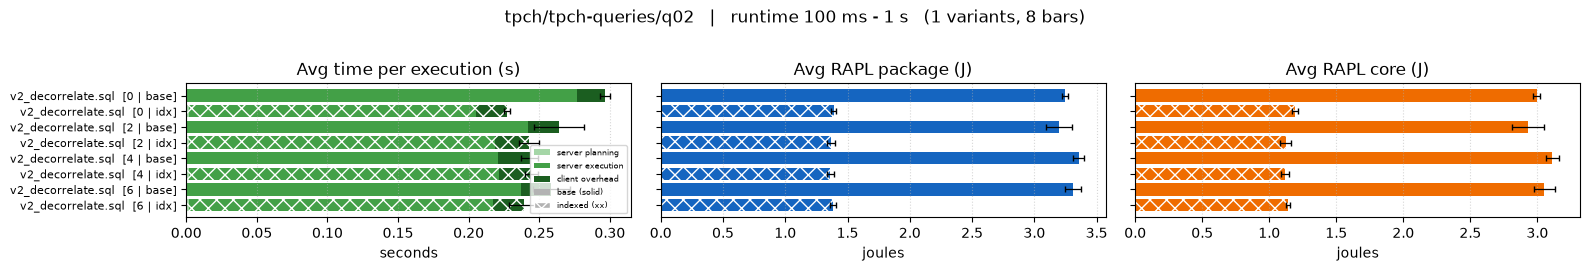

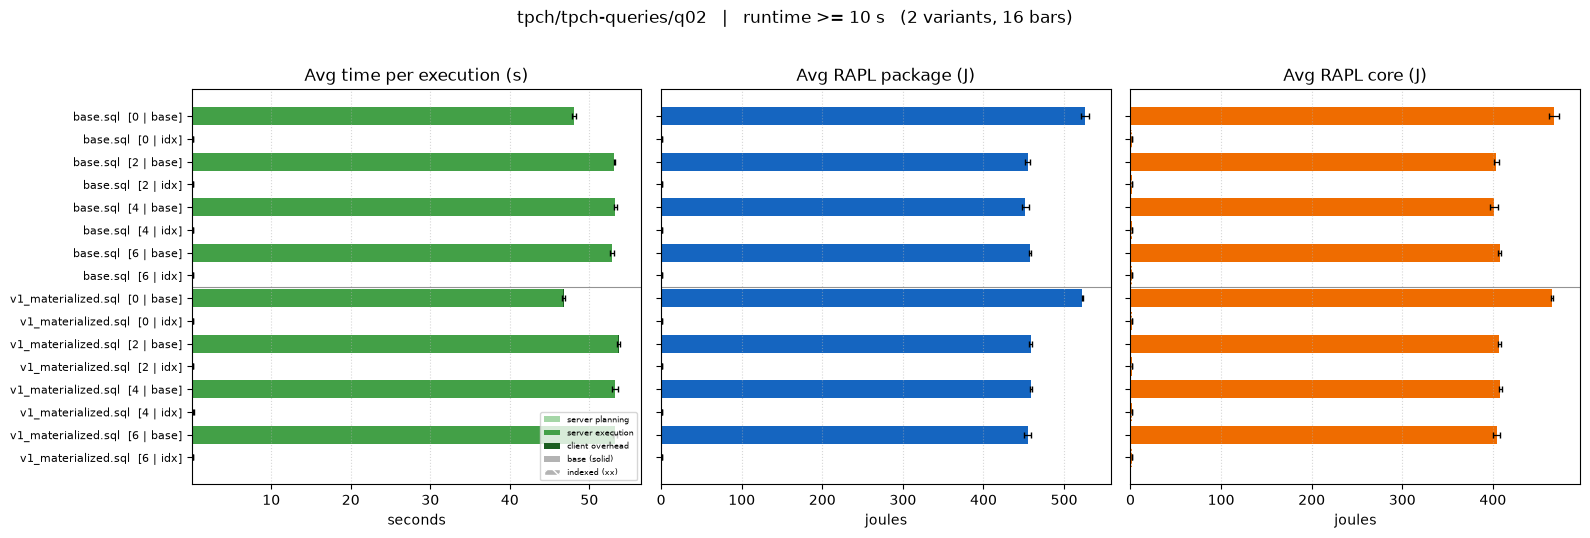

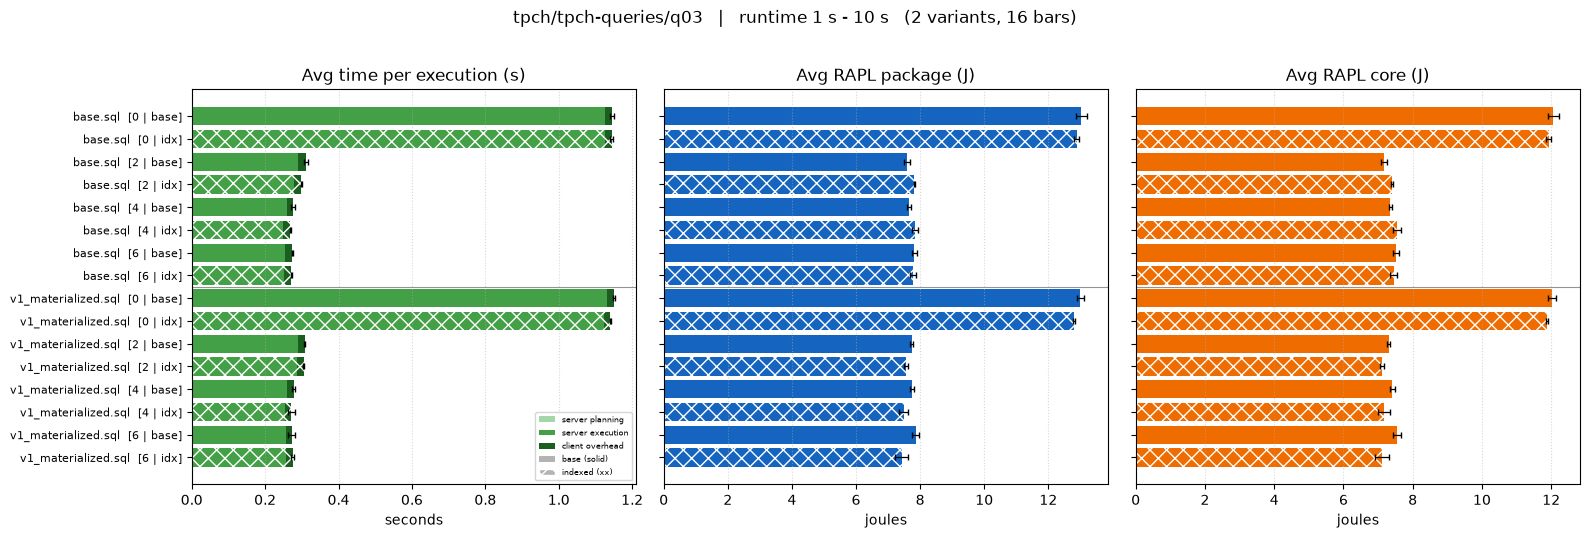

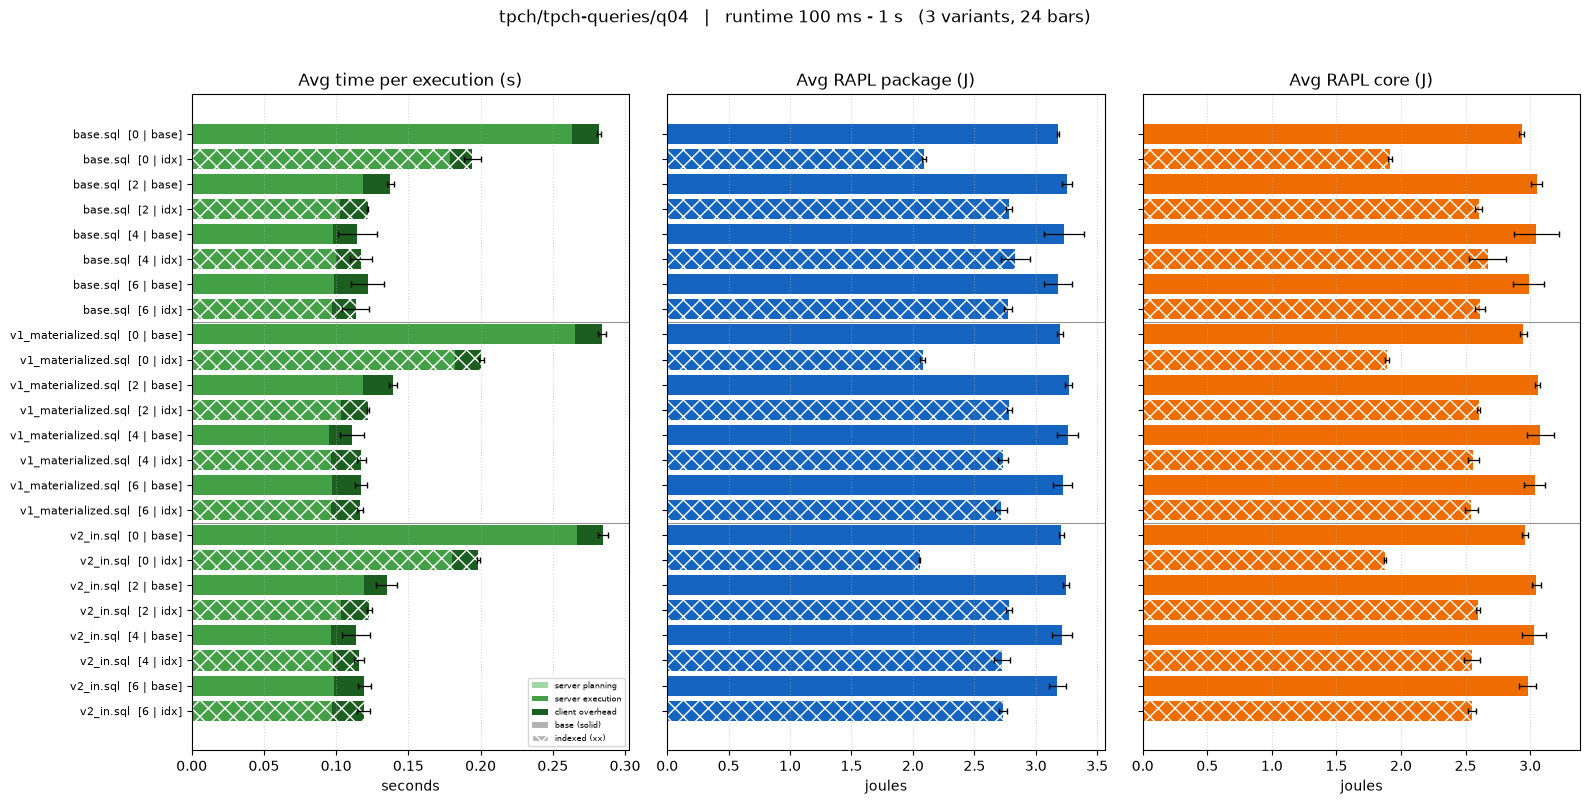

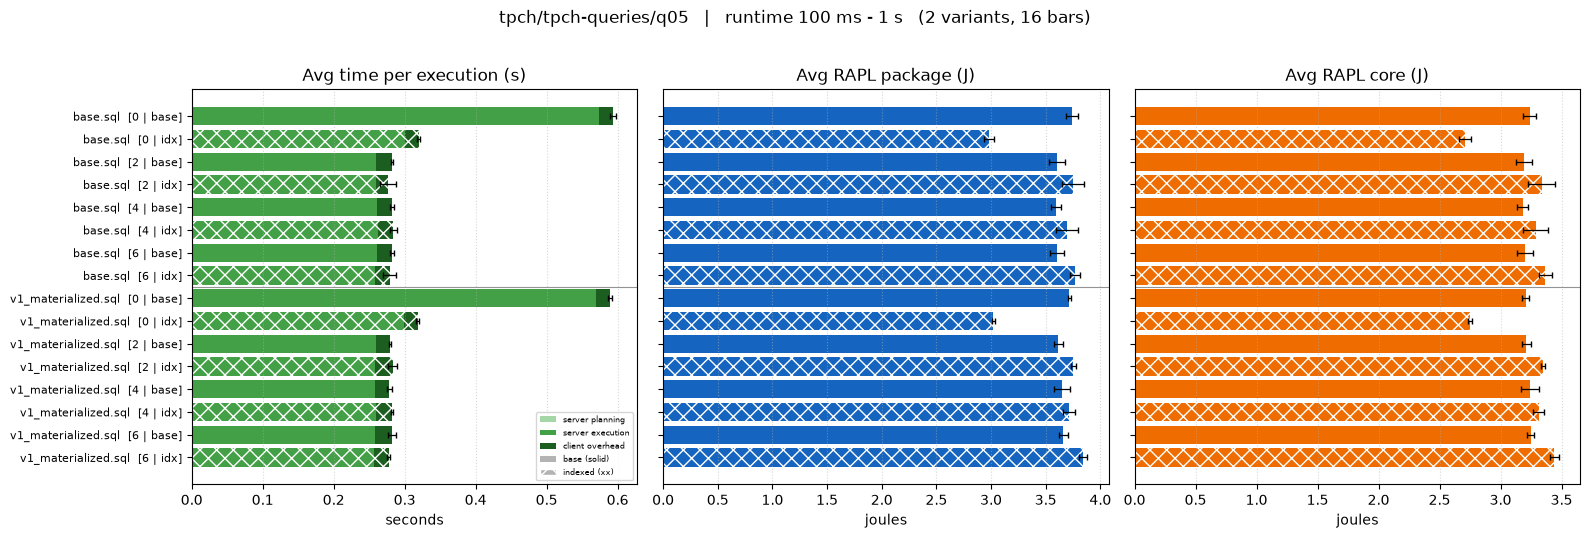

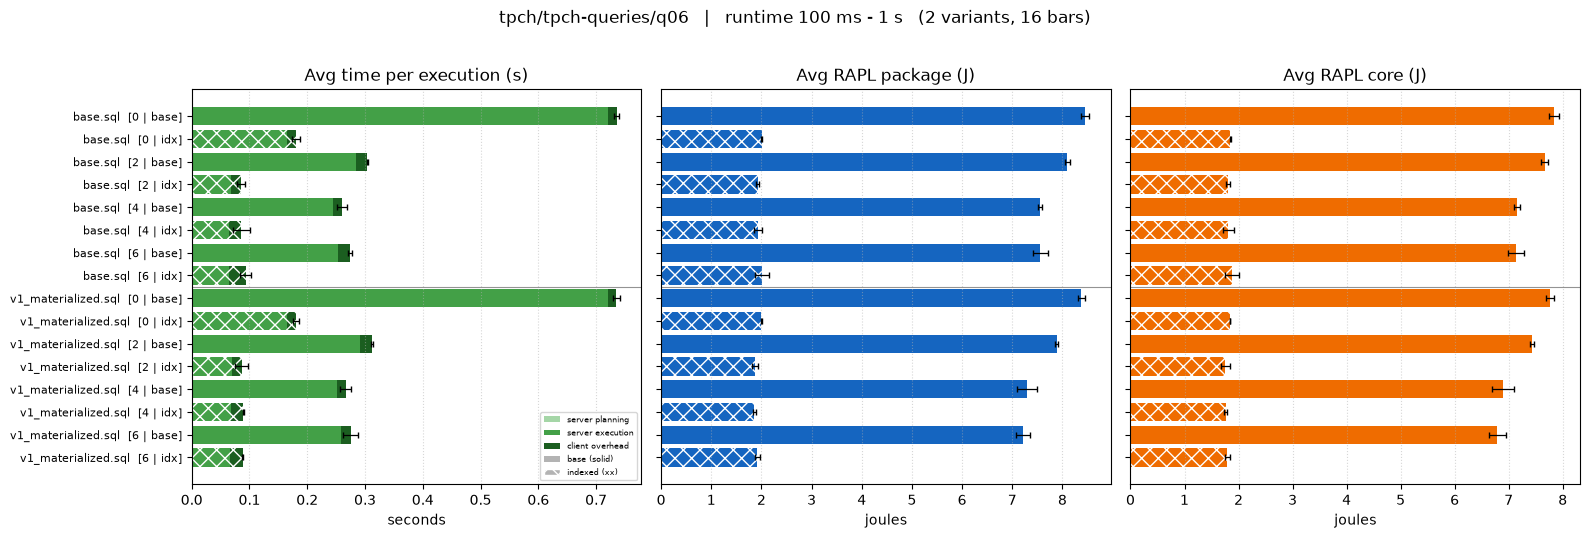

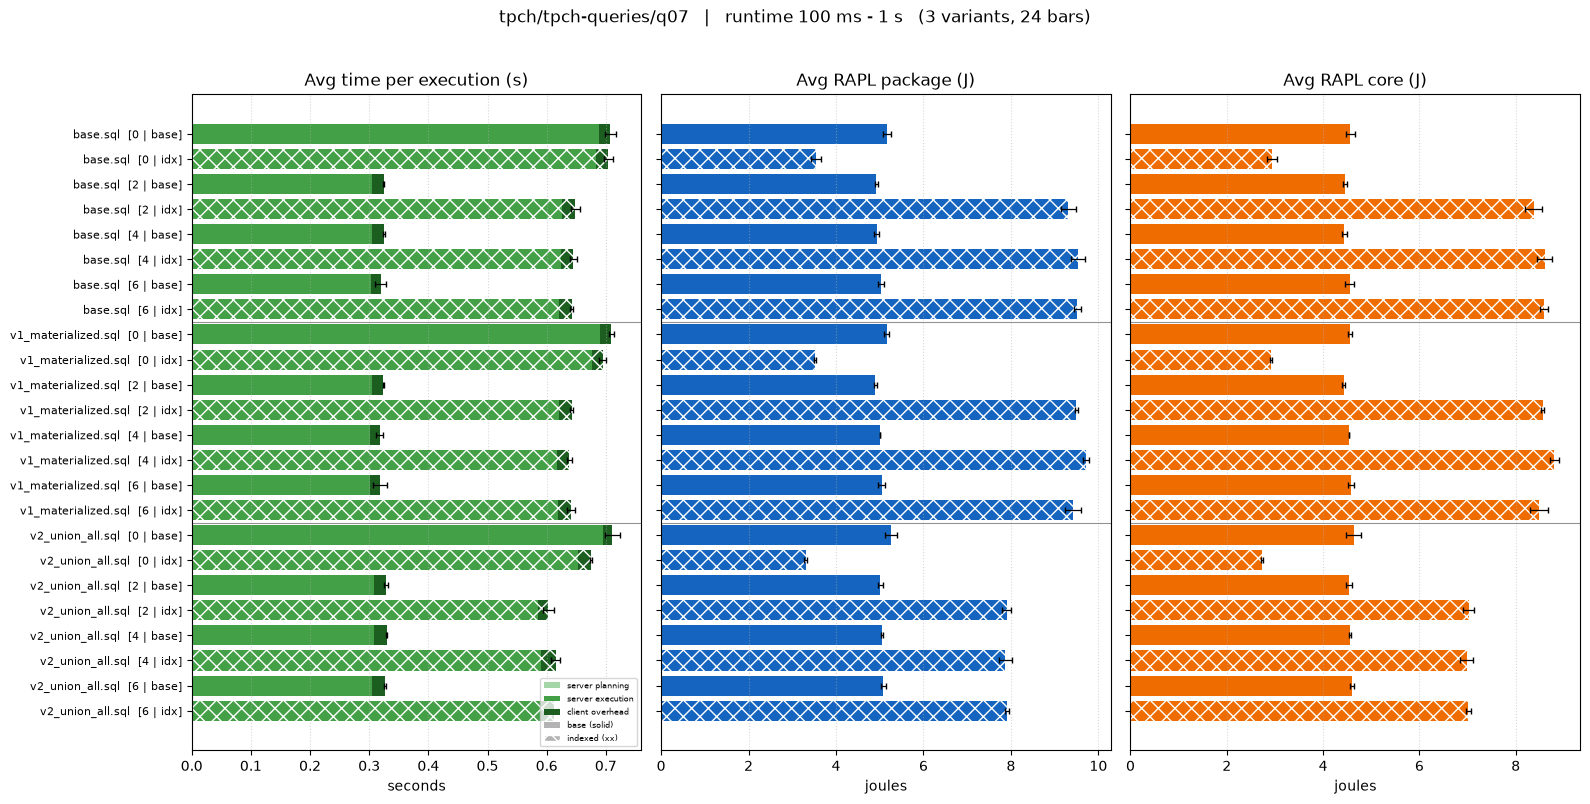

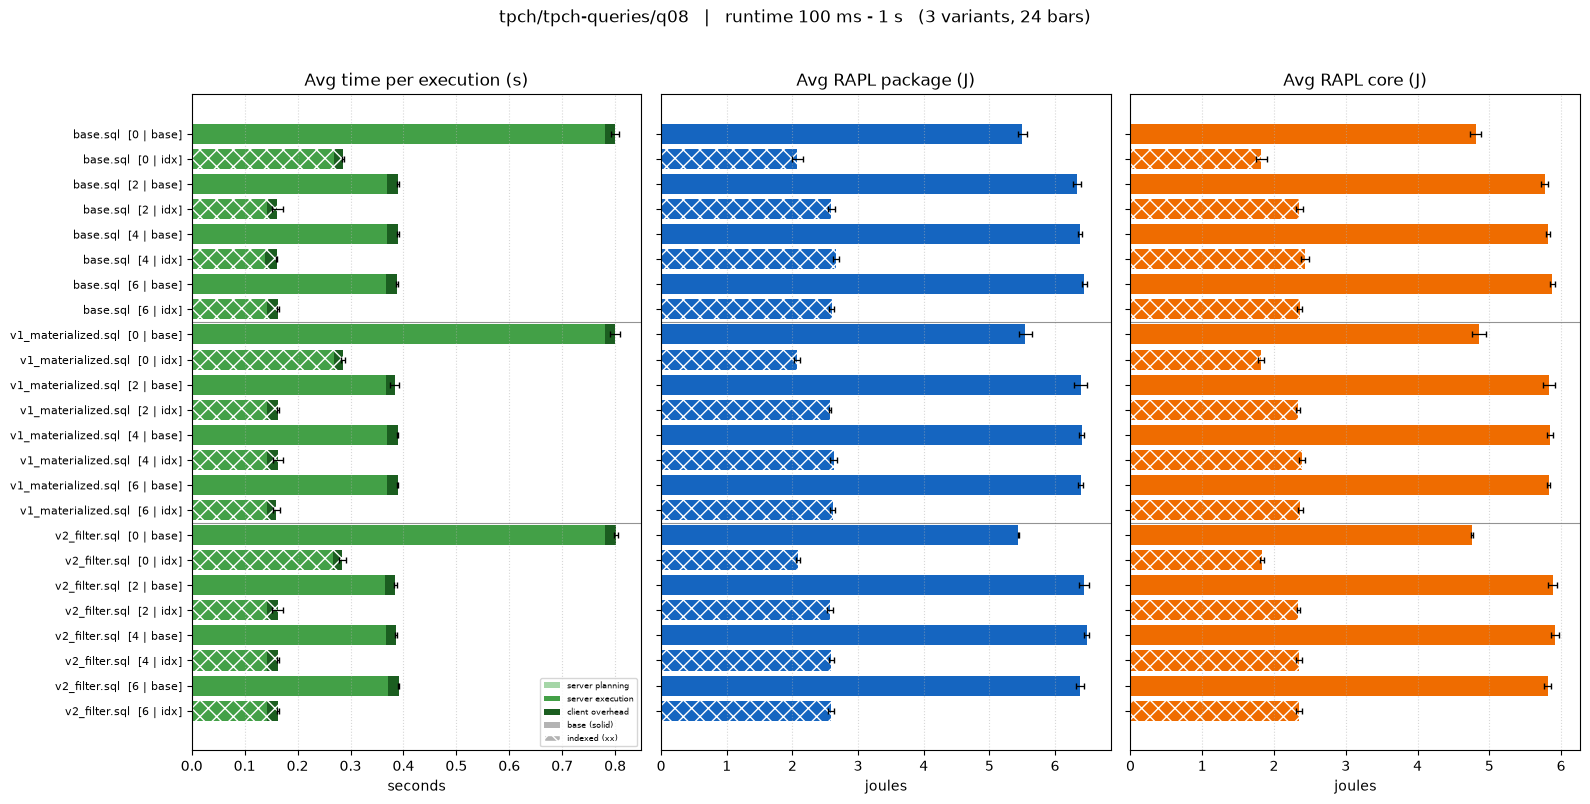

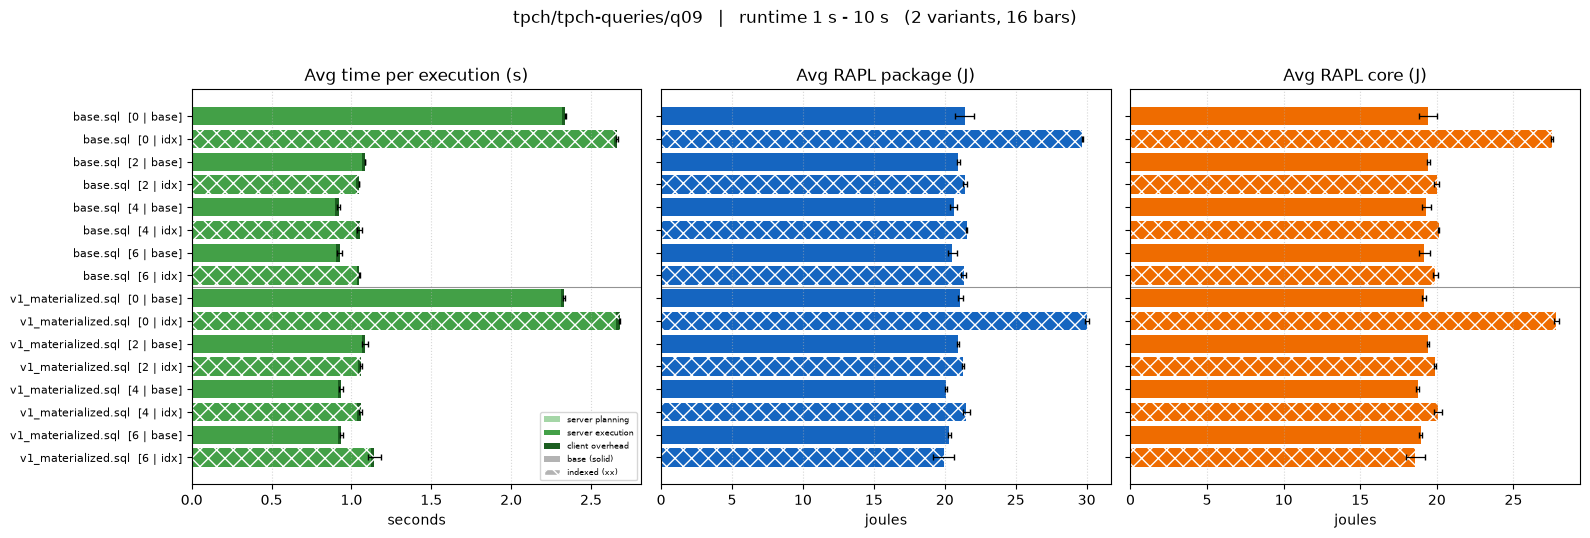

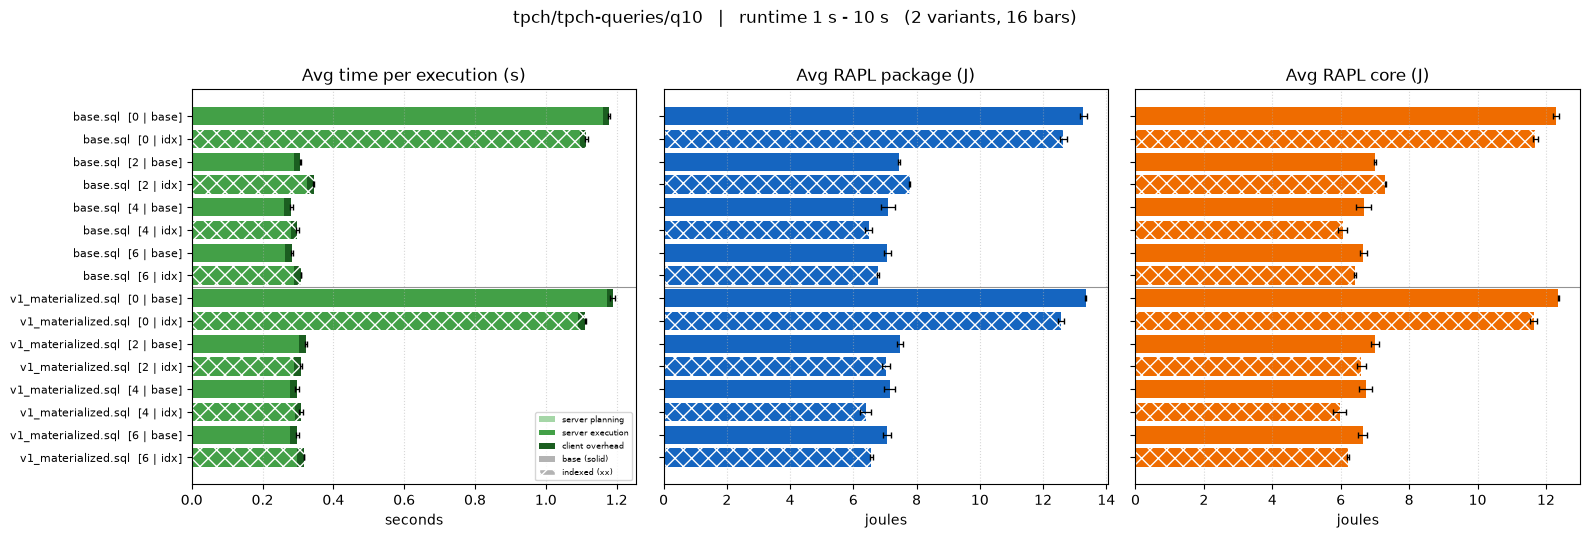

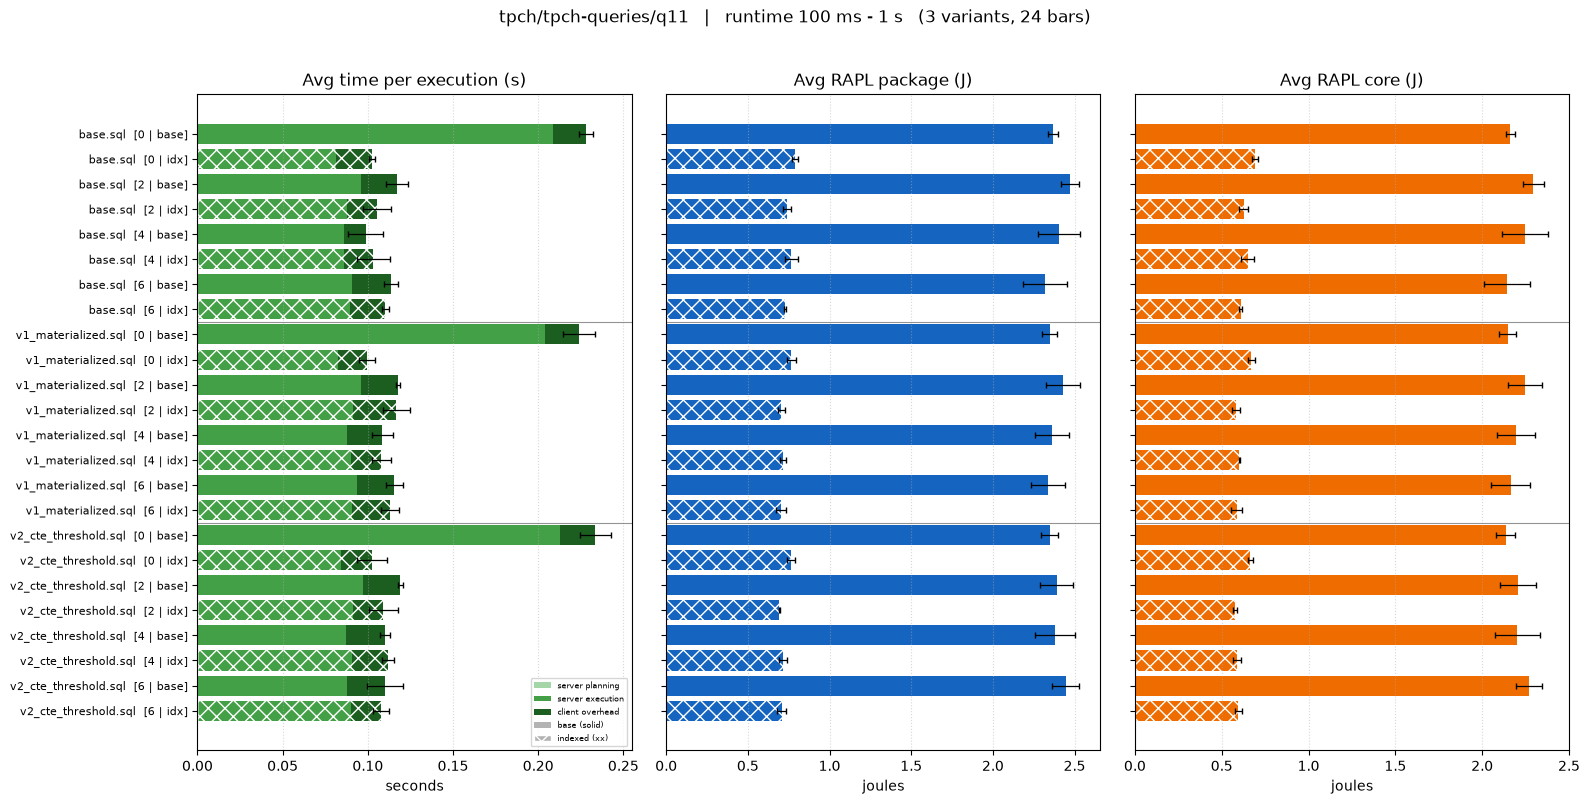

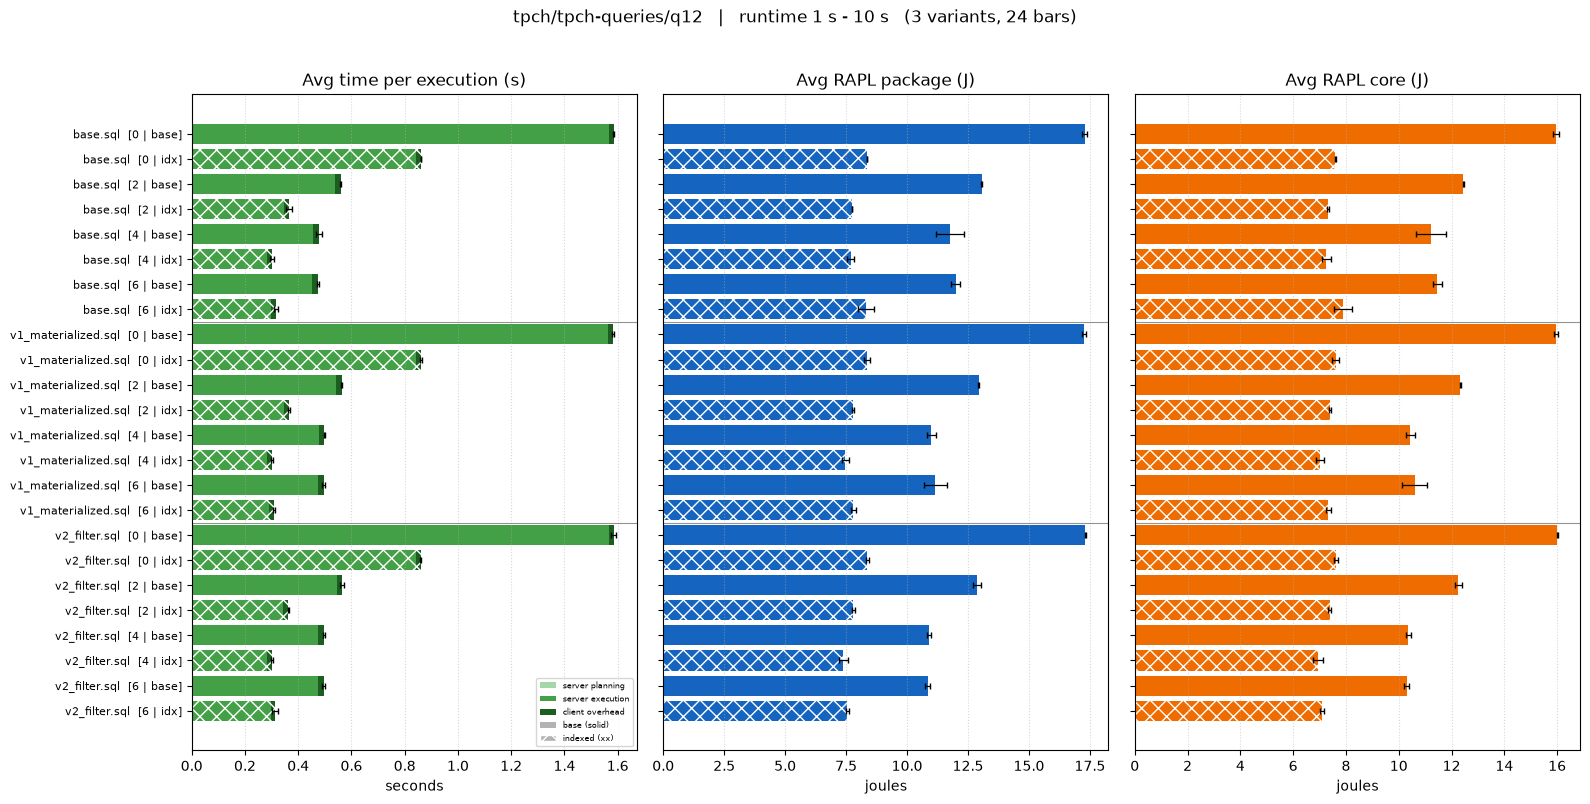

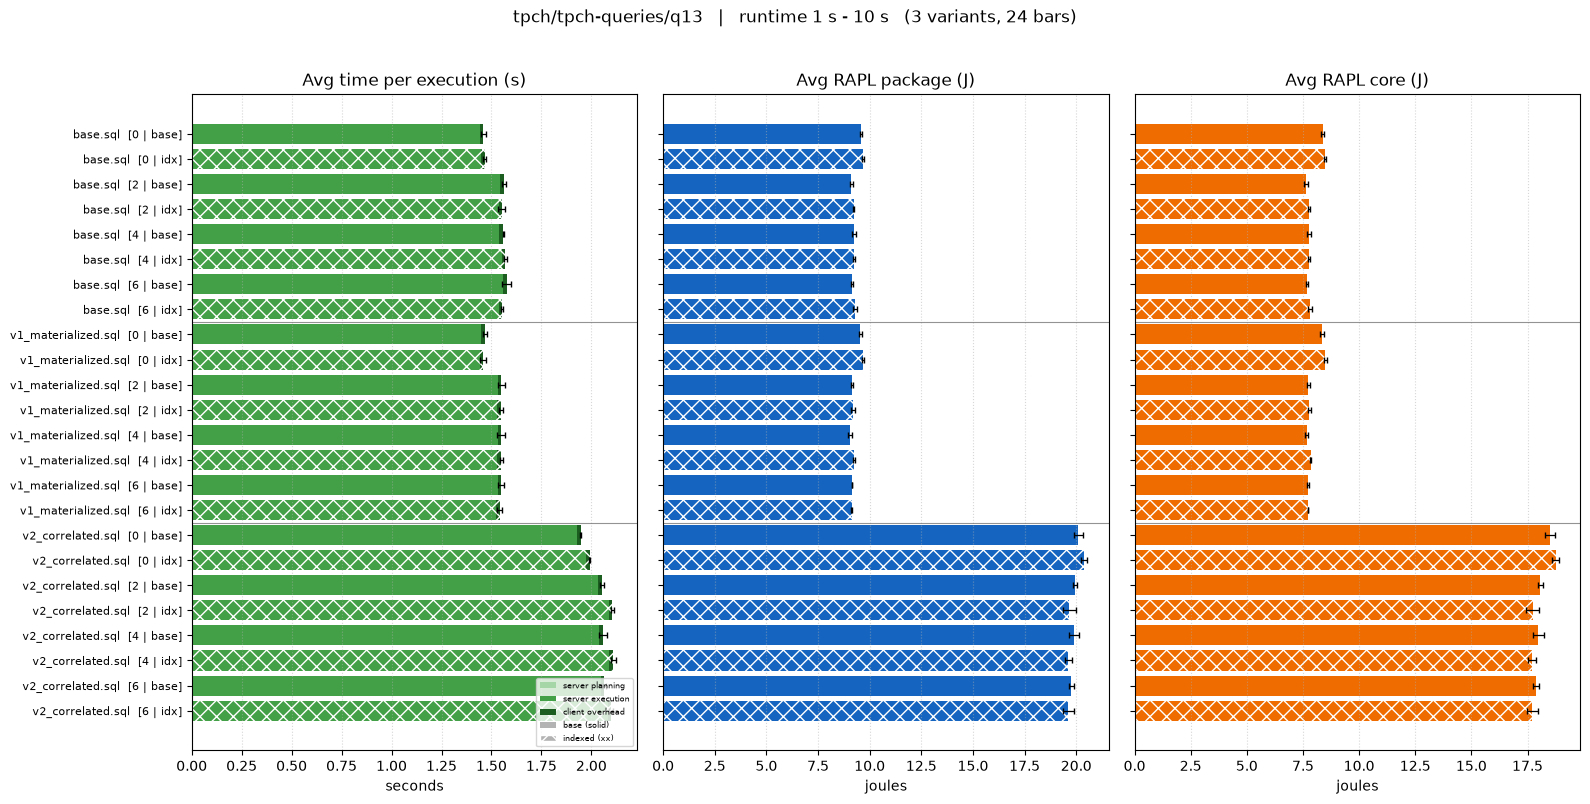

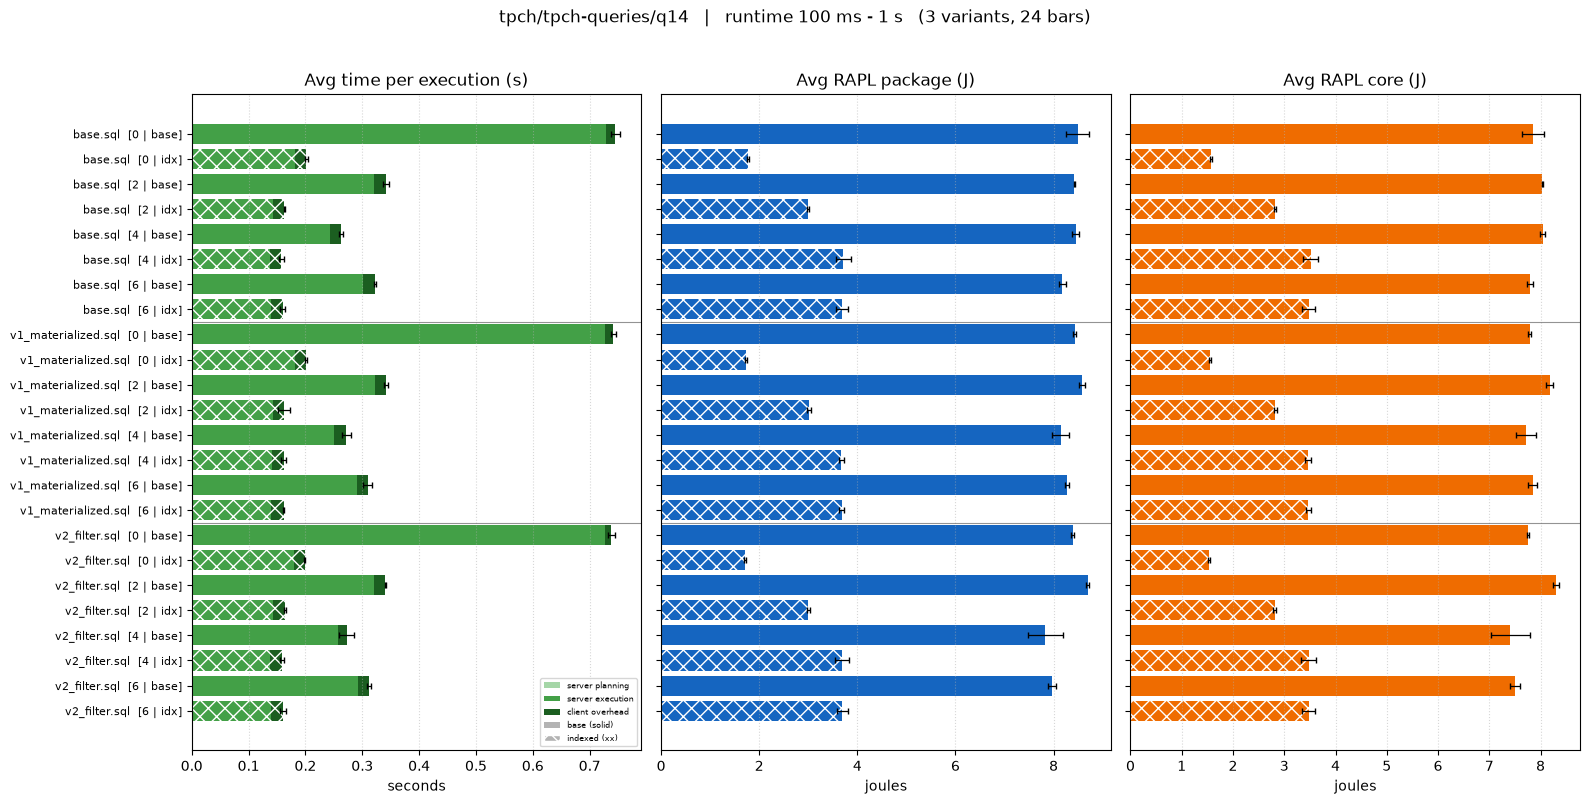

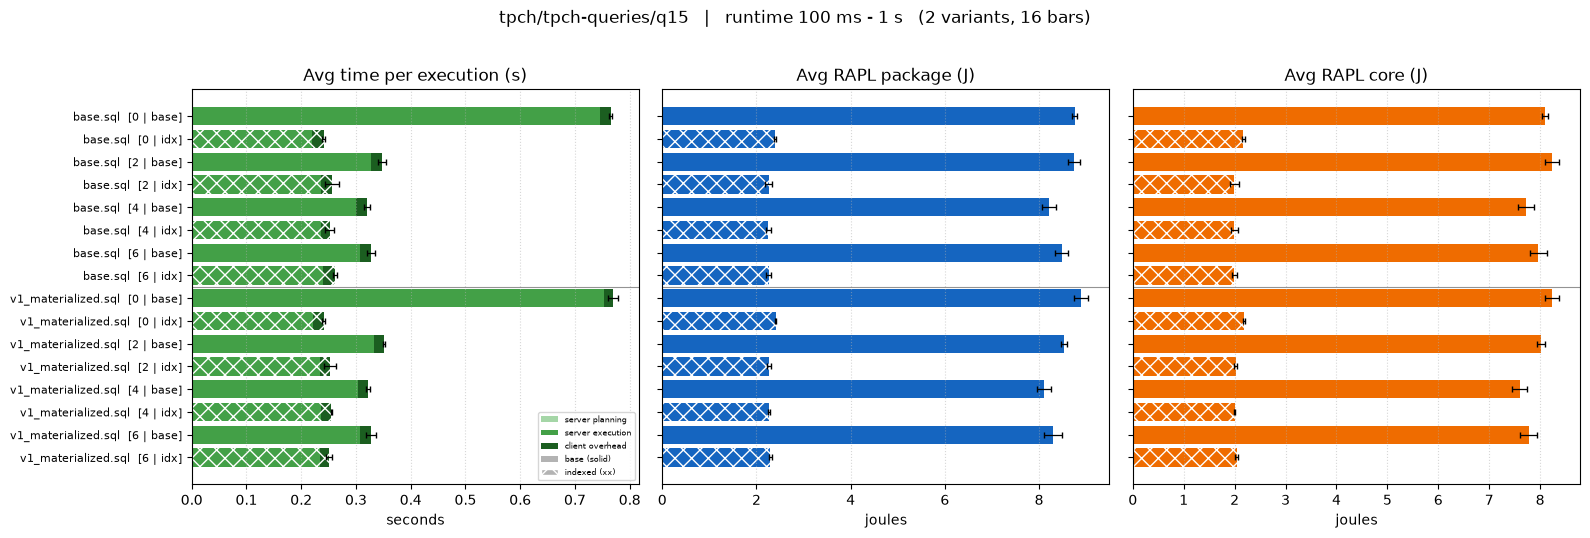

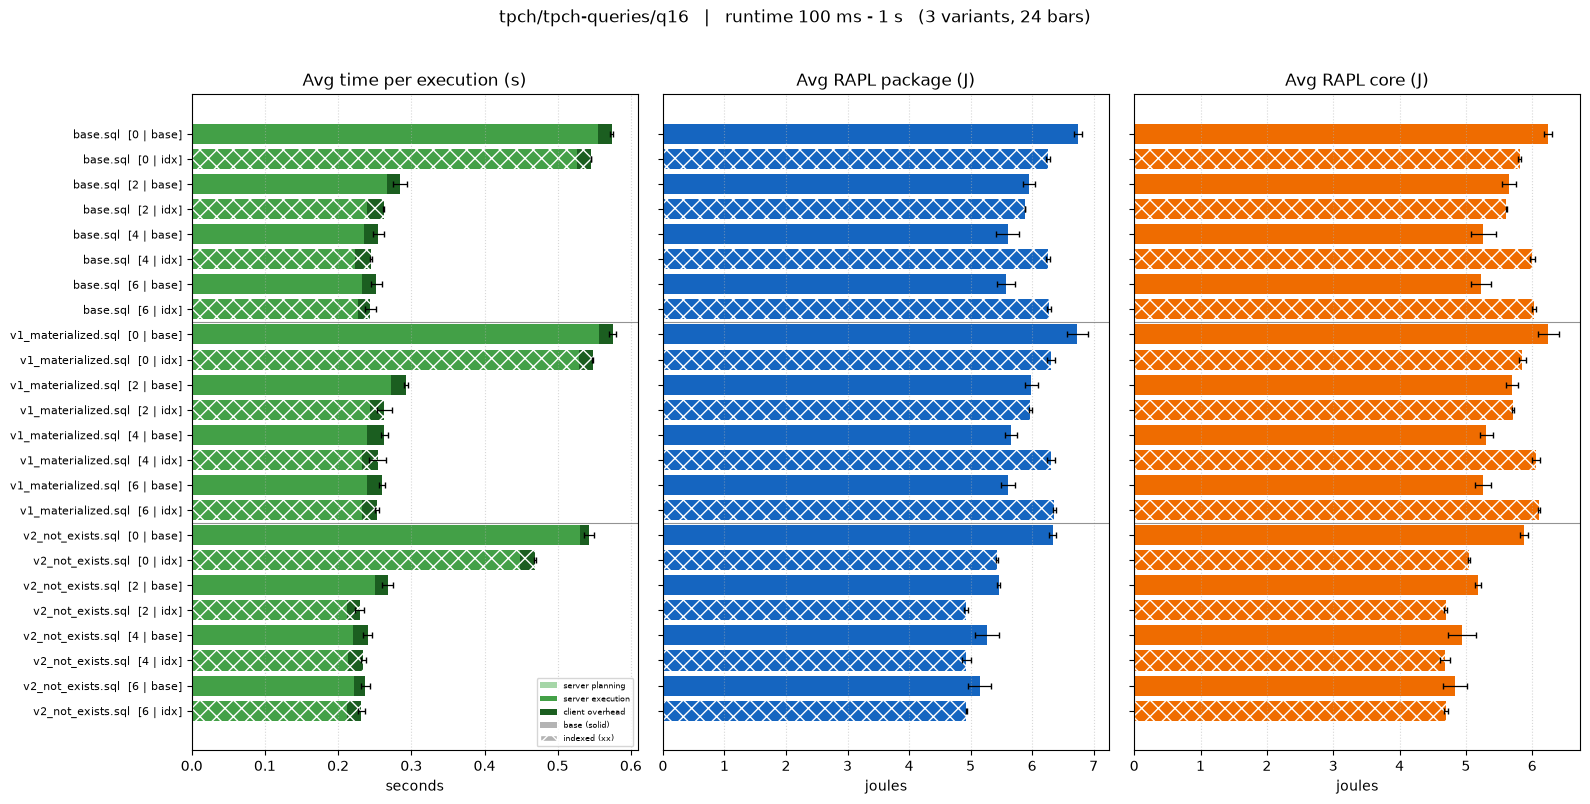

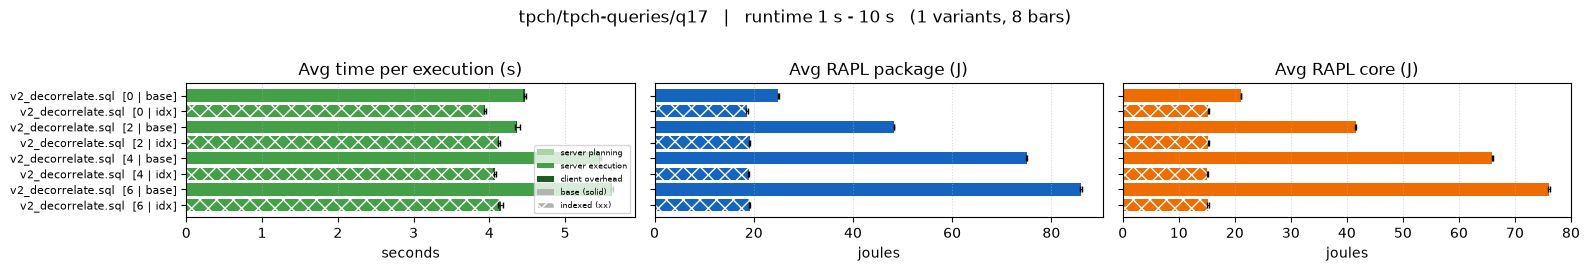

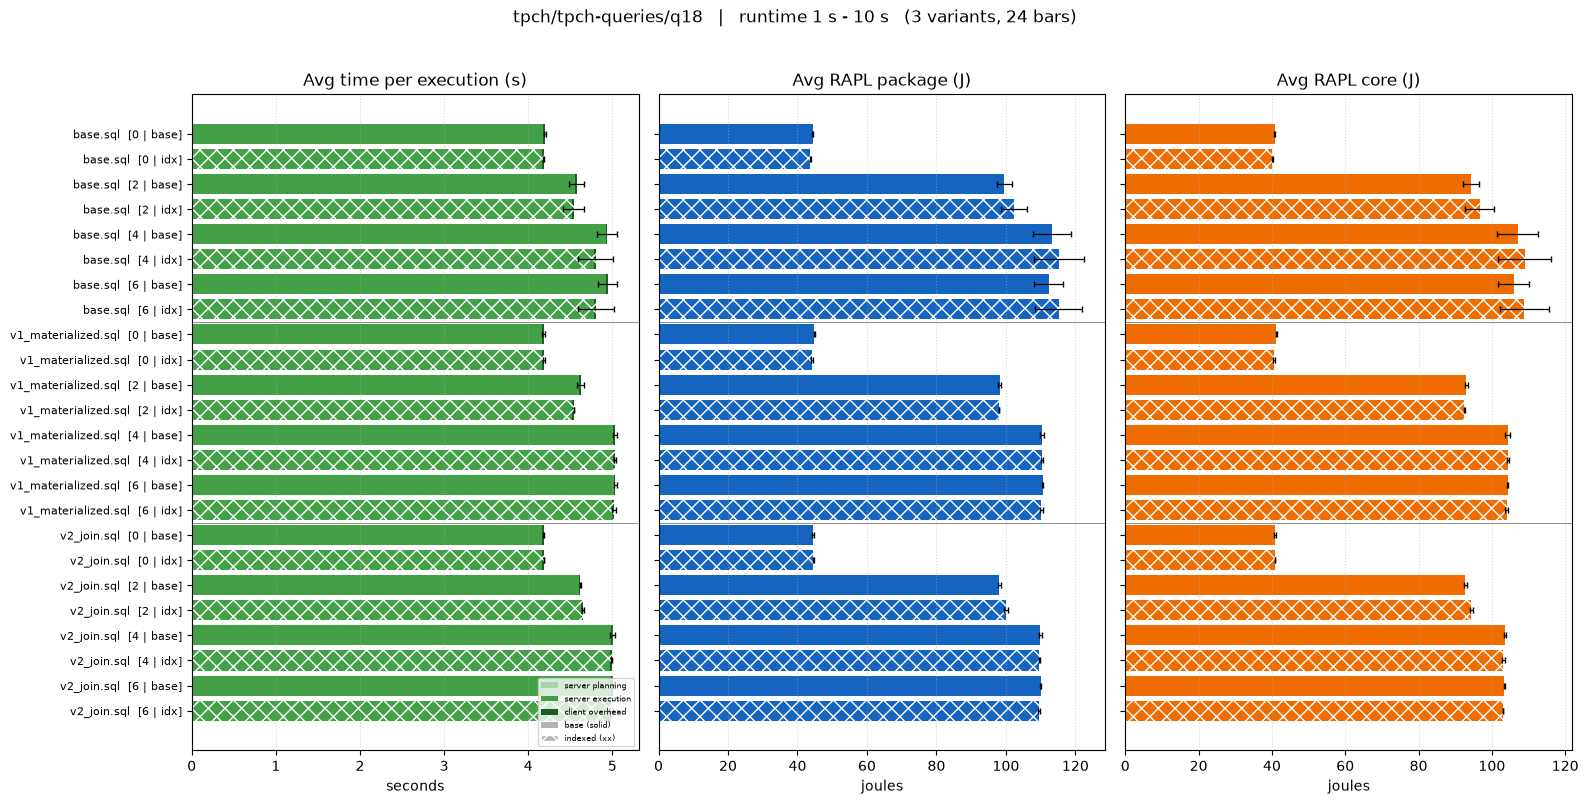

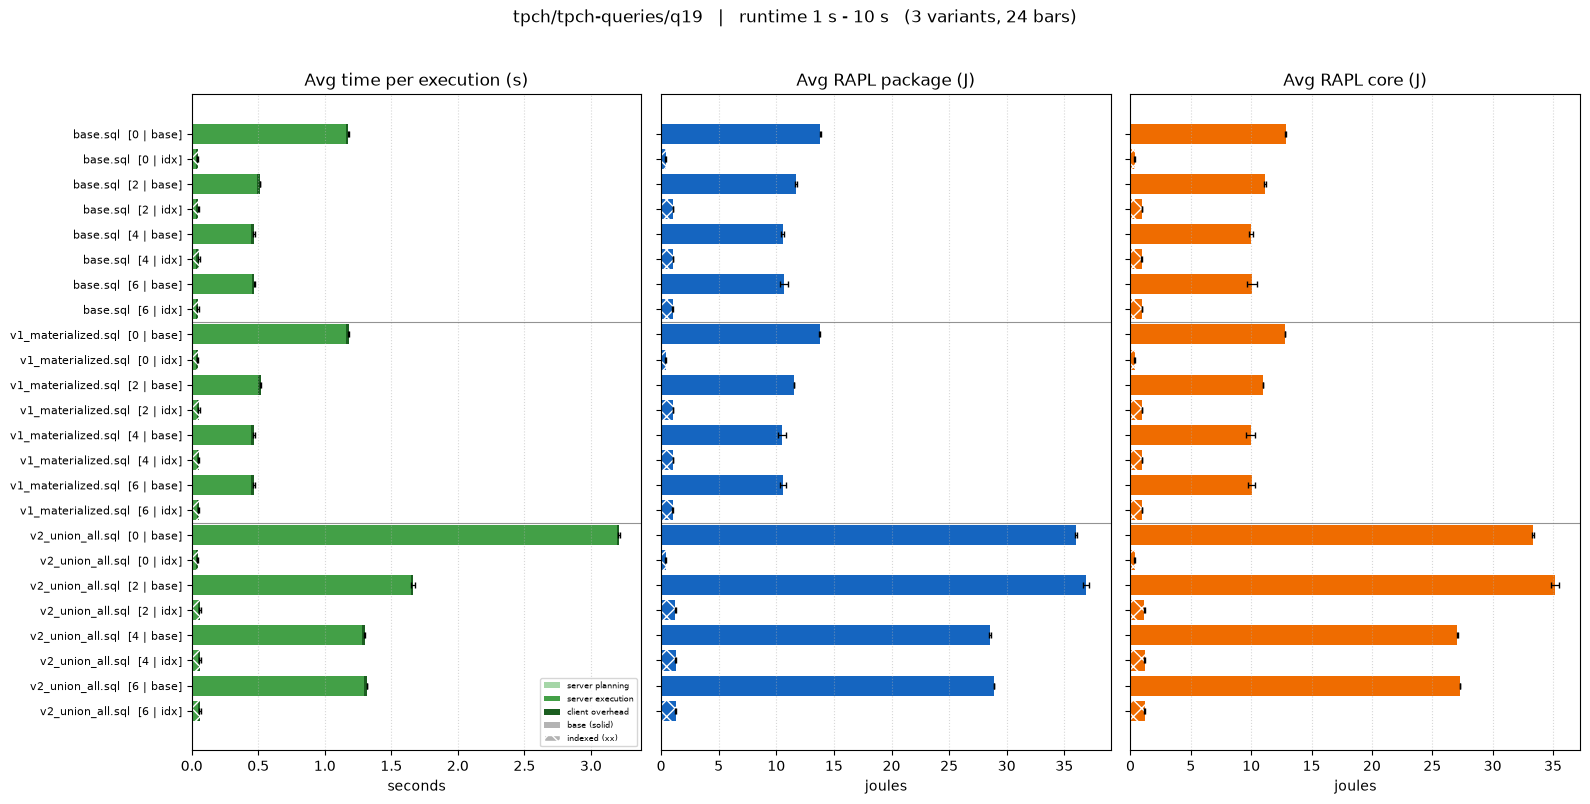

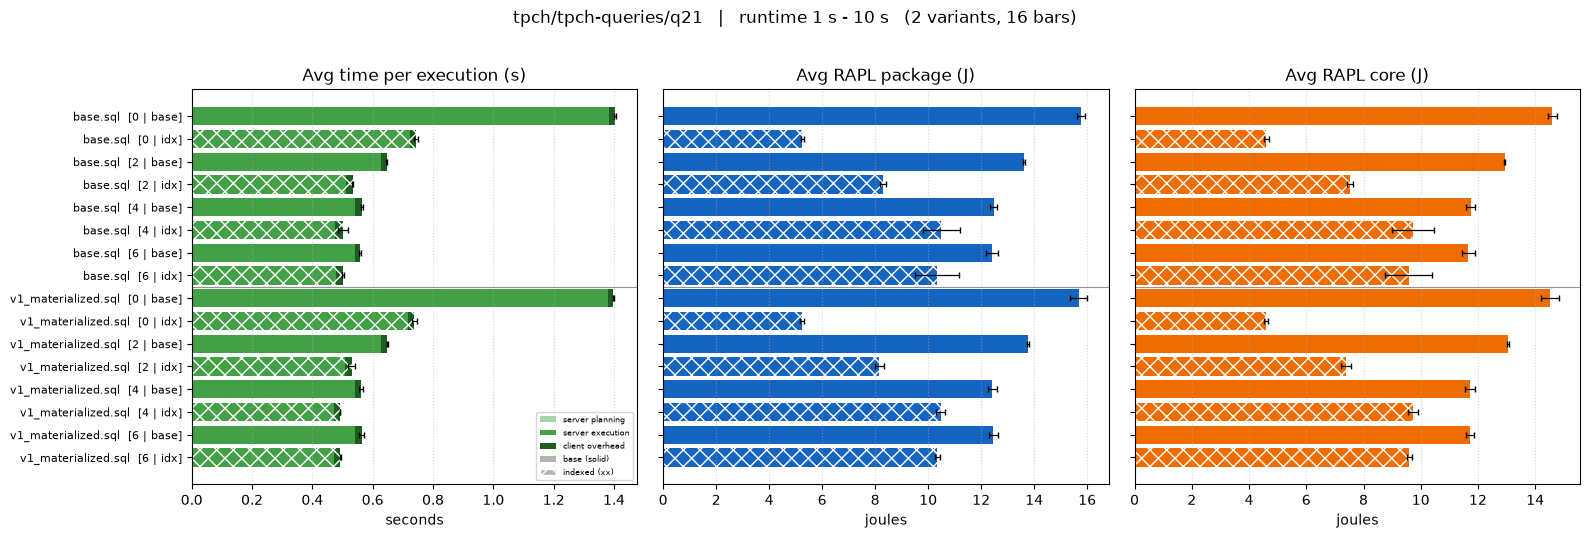

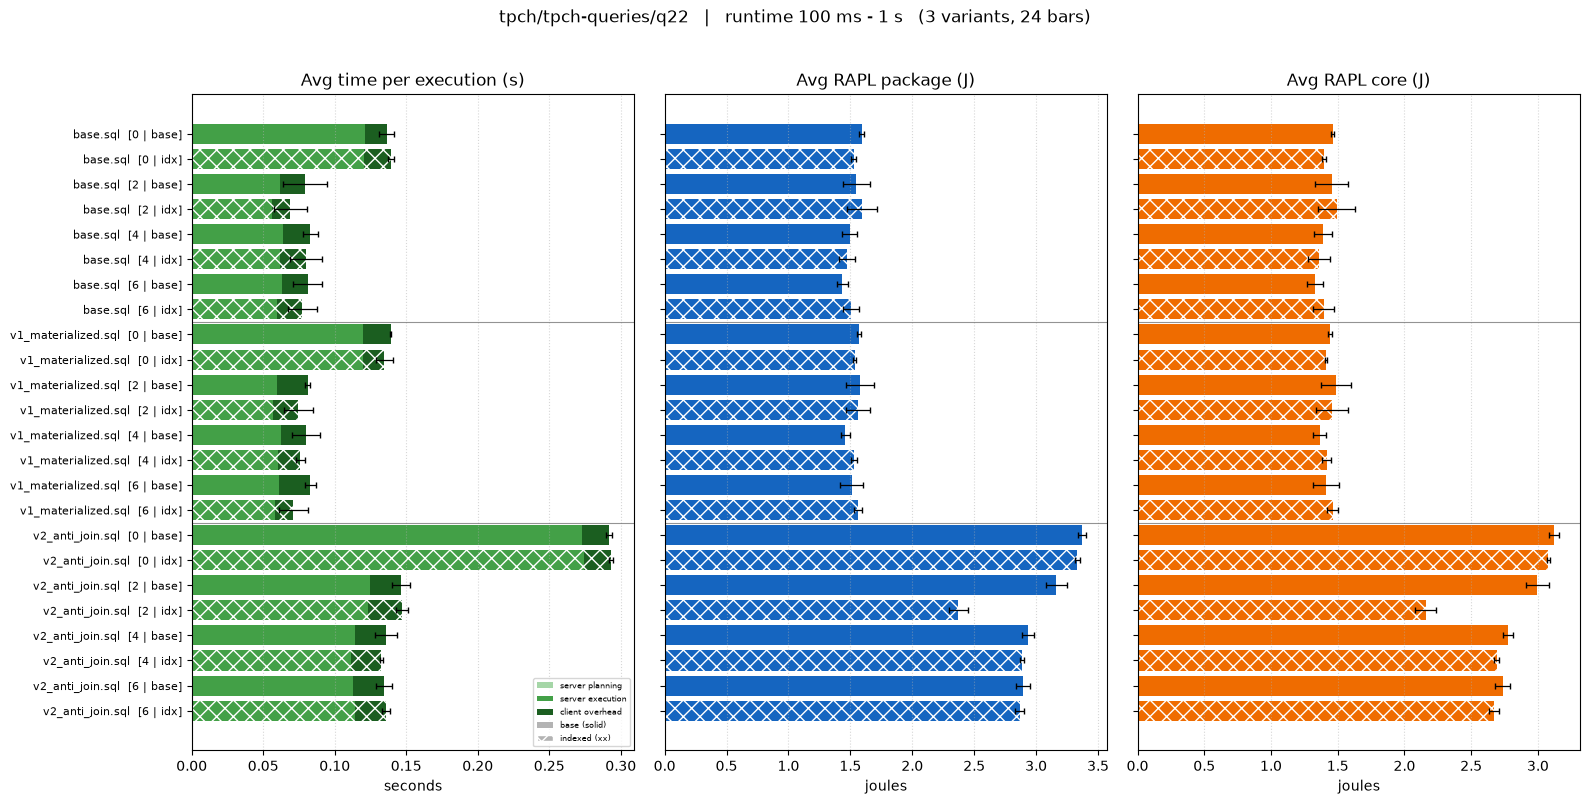

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GROUPS = None                      # query folders to draw; None = all
RUNTIME_BINS = [0.0, 0.1, 1.0, 10.0]   # bin START values in seconds
BIN_STAT = "max"                   # "max" | "median" | "min" | "mean"
MAX_FIGURES = 250

COMPONENTS = [
    ("plan_s", "#a5d6a7", "server planning"),
    ("exec_s", "#43a047", "server execution"),
    ("overhead_s", "#1b5e20", "client overhead"),
]
IDX_HATCH = "xx"
edges = list(RUNTIME_BINS) + [np.inf]


def fmt_t(s):
    return f"{s * 1000:g} ms" if s < 1 else f"{s:g} s"


def bin_name(i):
    lo, hi = edges[i], edges[i + 1]
    return f">= {fmt_t(lo)}" if np.isinf(hi) else f"{fmt_t(lo)} - {fmt_t(hi)}"


all_groups = sorted(data["group"].dropna().unique())
groups = all_groups if GROUPS is None else [g for g in all_groups if g in GROUPS]

qrep = data.groupby("query")["avg_time_s"].agg(BIN_STAT)
qbin = pd.Series(np.digitize(qrep.to_numpy(), edges[1:], right=False),
                 index=qrep.index)
qbin[qrep.isna()] = -1
dq = data.copy()
dq["_bin"] = dq["query"].map(qbin)
dq["_idx_ord"] = (dq["index_status"] == "idx").astype(int)
dq["plab"] = (dq["sql_file"] + "  [" + dq["plabel"]
              + " | " + dq["index_status"] + "]")

tasks = []
for group in groups:
    gb = dq.loc[dq["group"] == group, "_bin"]
    for i in sorted(b for b in gb.dropna().unique() if b >= 0):
        tasks.append((group, int(i)))
print(f"{len(groups)} query folder(s) -> {len(tasks)} figures")
if len(tasks) > MAX_FIGURES:
    print(f"capping to {MAX_FIGURES}")
    tasks = tasks[:MAX_FIGURES]


def hatch_idx(container, is_idx):
    for bar, ix in zip(container, is_idx):
        if ix:
            bar.set_hatch(IDX_HATCH)
            bar.set_edgecolor("white")
            bar.set_linewidth(0.0)


for group, i in tasks:
    g = dq[(dq["group"] == group) & (dq["_bin"] == i)].copy()
    g = g.sort_values(["sql_file", "pval", "_idx_ord"])
    y = np.arange(len(g))
    is_idx = (g["index_status"] == "idx").to_numpy()
    height = max(1.8, len(g) * 0.34)
    fig, axes = plt.subplots(1, 3, figsize=(16, height), sharey=True)

    ax = axes[0]
    left = np.zeros(len(g))
    for col, colour, _ in COMPONENTS:
        hatch_idx(ax.barh(y, g[col].fillna(0).to_numpy(dtype=float),
                          left=left, color=colour), is_idx)
        left += g[col].fillna(0).to_numpy(dtype=float)
    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)
    if ok.any():
        ax.errorbar(left[ok], y[ok], xerr=std[ok], fmt="none",
                    ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_title("Avg time per execution (s)"); ax.set_xlabel("seconds")
    handles = [Patch(facecolor=c, label=l) for _, c, l in COMPONENTS]
    handles += [Patch(facecolor="0.7", label="base (solid)"),
                Patch(facecolor="0.7", hatch=IDX_HATCH, edgecolor="white",
                      label="indexed (xx)")]
    ax.legend(handles=handles, fontsize=6, loc="lower right")

    for ax, col, scol, colour, title in (
        (axes[1], "avg_pkg_j", "pkg_j_std", "#1565c0", "Avg RAPL package (J)"),
        (axes[2], "avg_core_j", "core_j_std", "#ef6c00", "Avg RAPL core (J)"),
    ):
        vals = g[col].to_numpy(dtype=float)
        hatch_idx(ax.barh(y, np.nan_to_num(vals), color=colour), is_idx)
        estd = g[scol].to_numpy(dtype=float)
        eok = ~np.isnan(estd) & ~np.isnan(vals)
        if eok.any():
            ax.errorbar(vals[eok], y[eok], xerr=estd[eok], fmt="none",
                        ecolor="black", elinewidth=0.9, capsize=2)
        ax.set_title(title); ax.set_xlabel("joules")

    sql = g["sql_file"].to_numpy()
    bounds = [k - 0.5 for k in range(1, len(g)) if sql[k] != sql[k - 1]]
    for ax in axes:
        ax.grid(axis="x", linestyle=":", alpha=0.5)
        for yb in bounds:
            ax.axhline(yb, color="0.4", lw=0.8, alpha=0.7)
    axes[0].set_yticks(y); axes[0].set_yticklabels(g["plab"], fontsize=8)
    axes[0].invert_yaxis()
    fig.suptitle(f"{group}   |   runtime {bin_name(i)}   "
                 f"({g['sql_file'].nunique()} variants, {len(g)} bars)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 4. Parallelism — do more workers actually help?

The variable swept in these runs is **`max_parallel_workers_per_gather`** (2/4/6)
— the cap on workers a *single* `Gather` node may use (the server folder is named
`max_parallel_workers`, but that is the knob the benchmark script changes;
`max_worker_processes` = 8 and `parallel_leader_participation` = on are left at
their defaults). A query can only speed up if the planner gives it a parallel plan
**and** decides it wants more workers — and Postgres sizes that from the *relation
size*, so for an ~880 MB SF-1 table it tops out around 3–4 regardless of the cap.
The trade is classic: more workers → less wall-clock time but more cores drawing
power at once, so we look at **workers launched**, **runtime** and **energy**
together, and watch for the planner's ceiling.

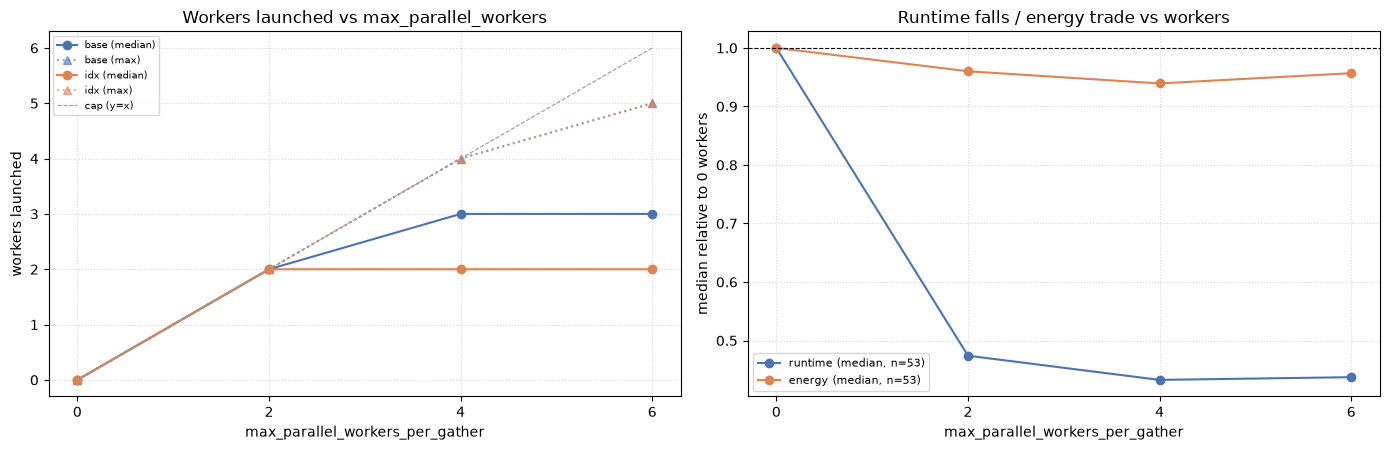

Runtime speedup from 0 -> 6 workers (base); energy_x >1 means also less energy:
                         speedup  energy_x  workers @6
qid                                                   
q03/v1_materialized.sql     4.23      1.65         3.0
q03/base.sql                4.19      1.67         3.0
q10/base.sql                4.17      1.88         3.0
q10/v1_materialized.sql     3.99      1.89         3.0
q12/base.sql                3.35      1.44         3.0
q12/v2_filter.sql           3.20      1.60         3.0
q12/v1_materialized.sql     3.19      1.55         3.0
q01/base.sql                3.07      1.51         5.0
q01/v1_materialized.sql     3.02      1.56         5.0
q06/base.sql                2.69      1.12         5.0

Least helped (or hurt) by more workers:
                         speedup  energy_x  workers @6
qid                                                   
q02/v1_materialized.sql     0.88      1.15         0.0
q18/base.sql                0.85      0.40         3.0

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# (1) workers actually launched vs the cap
for ix in IDX_ALL:
    sub = data[data["index_status"] == ix]
    grp = sub.groupby("pval")["workers"]
    med = grp.median()
    axes[0].plot(med.index, med.values, marker="o", color=colours[ix],
                 label=f"{ix} (median)")
    mx = grp.max()
    axes[0].plot(mx.index, mx.values, marker="^", ls=":", color=colours[ix],
                 alpha=0.6, label=f"{ix} (max)")
axes[0].plot(PVALS, PVALS, color="0.6", lw=0.8, ls="--", label="cap (y=x)")
set_xaxis(axes[0])
axes[0].set_ylabel("workers launched")
axes[0].set_title("Workers launched vs max_parallel_workers")
axes[0].grid(linestyle=":", alpha=0.5); axes[0].legend(fontsize=7)

# (2) runtime & energy relative to the fewest workers (base)
base = data[data["index_status"] == "base"]
for metric, name, c in (("avg_time_s", "runtime", "#4c72b0"),
                        ("avg_pkg_j", "energy", "#dd8452")):
    piv = base.pivot_table(index="qid", columns="pval", values=metric).reindex(columns=PVALS).dropna(how="any")
    rel = piv.div(piv[PVALS[0]], axis=0)
    axes[1].plot(PVALS, rel.median().values, marker="o", color=c,
                 label=f"{name} (median, n={len(rel)})")
axes[1].axhline(1.0, color="k", lw=0.8, ls="--")
set_xaxis(axes[1])
axes[1].set_ylabel(f"median relative to {p_label(PVALS[0])} workers")
axes[1].set_title("Runtime falls / energy trade vs workers")
axes[1].grid(linestyle=":", alpha=0.5); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

# queries that scale best with more workers
rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS).dropna(how="any")
en = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS).dropna(how="any")
scale = pd.DataFrame({
    "speedup": rt[PVALS[0]] / rt[PVALS[-1]],
    "energy_x": en[PVALS[0]] / en[PVALS[-1]],
    f"workers @{p_label(PVALS[-1])}": base[base["pval"] == PVALS[-1]].set_index("qid")["workers"],
}).sort_values("speedup", ascending=False)
print(f"Runtime speedup from {p_label(PVALS[0])} -> {p_label(PVALS[-1])} workers (base); "
      "energy_x >1 means also less energy:")
print(scale.head(10).round(2).to_string())
print("\nLeast helped (or hurt) by more workers:")
print(scale.tail(5).round(2).to_string())

## 5. Runtime & energy vs max_parallel_workers_per_gather — where does tuning pay off?

For each query, runtime and package energy are taken relative to their value at
the **smallest** max_parallel_workers_per_gather setting, so `1.0` = same as the smallest and `< 1` =
faster / leaner. The heavy line is the median over queries; the summed totals per
setting say which value is best **overall**.

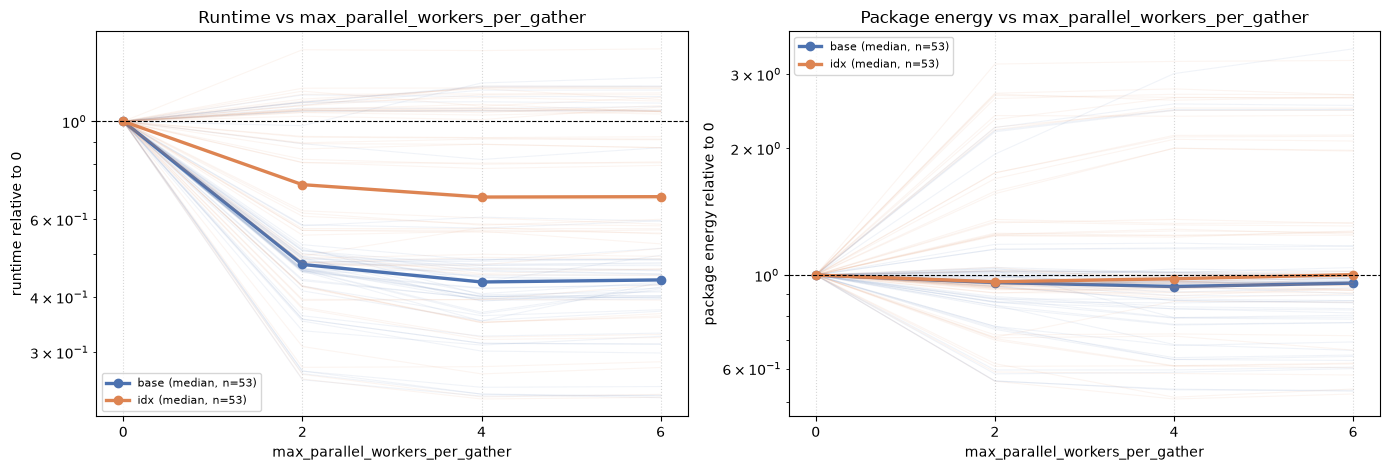

Total runtime / energy across the common query set, by max_parallel_workers_per_gather:
index_status  pval  total_runtime_s  total_energy_j  queries
        base     0            164.8          1752.3       53
        base     2            150.2          1732.1       53
        base     4            149.9          1752.7       53
        base     6            150.1          1765.3       53
         idx     0             54.7           536.7       53
         idx     2             39.2           657.6       53
         idx     4             39.3           686.0       53
         idx     6             39.5           686.3       53
  [base] fastest total: 4  |  lowest energy: 2
  [idx] fastest total: 2  |  lowest energy: 0


In [5]:
def relative(metric, ix):
    # use only the values this variant covers broadly, so an incomplete point
    # (e.g. one query at the largest setting) doesn't collapse the whole line
    sub = data[data["index_status"] == ix]
    cov = sub.groupby("pval")["qid"].nunique()
    good = [m for m in PVALS if cov.get(m, 0) >= 0.5 * cov.max()]
    piv = sub.pivot_table(index="qid", columns="pval", values=metric).reindex(columns=good)
    piv = piv.dropna(how="any")
    rel = piv.div(piv[good[0]], axis=0) if not piv.empty else piv
    return good, piv, rel


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric, nice in ((axes[0], "avg_time_s", "runtime"),
                         (axes[1], "avg_pkg_j", "package energy")):
    for ix in IDX_ALL:
        good, piv, rel = relative(metric, ix)
        if rel.empty:
            continue
        for _, row in rel.iterrows():
            ax.plot(good, row.values, color=colours[ix], alpha=0.08, lw=0.8)
        ax.plot(good, rel.median().values, color=colours[ix], marker="o",
                lw=2.4, label=f"{ix} (median, n={len(rel)})")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set_yscale("log")
    set_xaxis(ax)
    ax.set_ylabel(f"{nice} relative to {p_label(PVALS[0])}")
    ax.set_title(f"{nice.capitalize()} vs max_parallel_workers_per_gather"); ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

tot = data.groupby(["index_status", "pval"]).agg(
    total_runtime_s=("avg_time_s", "sum"),
    total_energy_j=("avg_pkg_j", "sum"),
    queries=("qid", "nunique")).reset_index()
print("Total runtime / energy across the common query set, by max_parallel_workers_per_gather:")
print(tot.round(1).to_string(index=False))
for ix in IDX_ALL:
    t = tot[tot["index_status"] == ix].set_index("pval")
    bt = t["total_runtime_s"].idxmin(); be = t["total_energy_j"].idxmin()
    print(f"  [{ix}] fastest total: {p_label(bt)}  |  lowest energy: {p_label(be)}")

## 6. Best max_parallel_workers_per_gather per query — by runtime

Not every query benefits from the largest setting. For each query (base) we pick
the max_parallel_workers_per_gather value with the lowest **runtime** (needing a margin over the
runner-up to count, else it is a **tie / flat**) and tally how many queries prefer
each value.

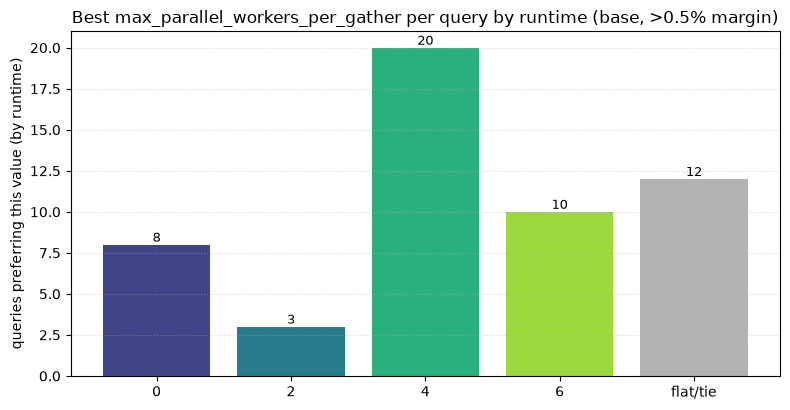

12/53 queries are flat on runtime (no value wins by >0.5%).

Queries that gain most runtime from the largest max_parallel_workers_per_gather (base, speedup 0 -> 6):
qid
q03/v1_materialized.sql    4.23
q03/base.sql               4.19
q10/base.sql               4.17
q10/v1_materialized.sql    3.99
q12/base.sql               3.35
q12/v2_filter.sql          3.20
q12/v1_materialized.sql    3.19
q01/base.sql               3.07
q01/v1_materialized.sql    3.02
q06/base.sql               2.69


In [6]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by runtime)")
ax.set_title(f"Best max_parallel_workers_per_gather per query by runtime (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on runtime "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most runtime from the largest max_parallel_workers_per_gather (base, "
      f"speedup {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6b. Full ranking by runtime — how every value places across queries

Section 6 counted only each query's *winner*. This ranks **all** max_parallel_workers_per_gather values
per query into 1st / 2nd / 3rd / … place (base **runtimes**) with the same
`MARGIN_PCT`: values within that margin of a place's best **share** that place.
Every bar therefore totals the query count, coloured by the place that value took
— a mostly-green value is the safe default; lots of red means it is usually the
worst choice.

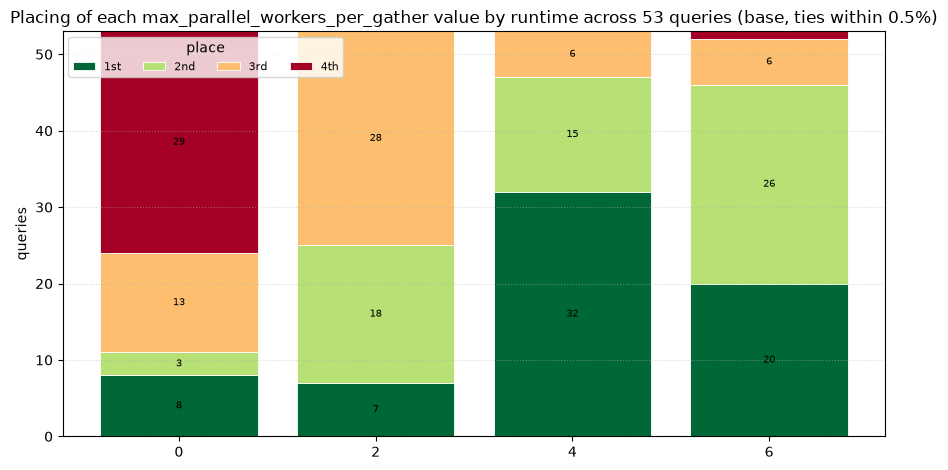

runtime placings across 53 queries (ties within 0.5% share a place):
   1st  2nd  3rd  4th
0    8    3   13   29
2    7   18   28    0
4   32   15    6    0
6   20   26    6    1


In [7]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each max_parallel_workers_per_gather value by runtime across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("mpw_placing.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"runtime placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 6c. Best max_parallel_workers_per_gather per query — by energy

The same tally as §6, but ranking each query's values by **package energy**
(`avg_pkg_j`) instead of runtime. Because energy = power × time and power is not
constant across settings (e.g. more parallel workers draw more watts), the
lowest-energy value can differ from the fastest one — this is where that shows up.

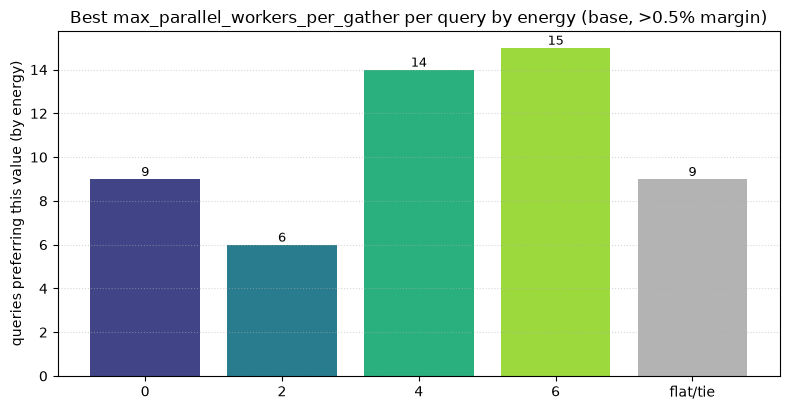

9/53 queries are flat on energy (no value wins by >0.5%).

Queries that gain most energy from the largest max_parallel_workers_per_gather (base, energy ratio 0 -> 6):
qid
q10/v1_materialized.sql    1.89
q10/base.sql               1.88
q03/base.sql               1.67
q03/v1_materialized.sql    1.65
q12/v2_filter.sql          1.60
q01/v1_materialized.sql    1.56
q12/v1_materialized.sql    1.55
q01/base.sql               1.51
q12/base.sql               1.44
q19/v1_materialized.sql    1.30


In [8]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by energy)")
ax.set_title(f"Best max_parallel_workers_per_gather per query by energy (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on energy "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most energy from the largest max_parallel_workers_per_gather (base, "
      f"energy ratio {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6d. Full ranking by energy — how every value places across queries

The §6b placings, but ranking all max_parallel_workers_per_gather values per query by **package energy**
rather than runtime. Compare the colours against §6b: a value that is usually
fastest but not usually lowest-energy (or vice-versa) reveals a time-vs-energy
trade-off in this parameter.

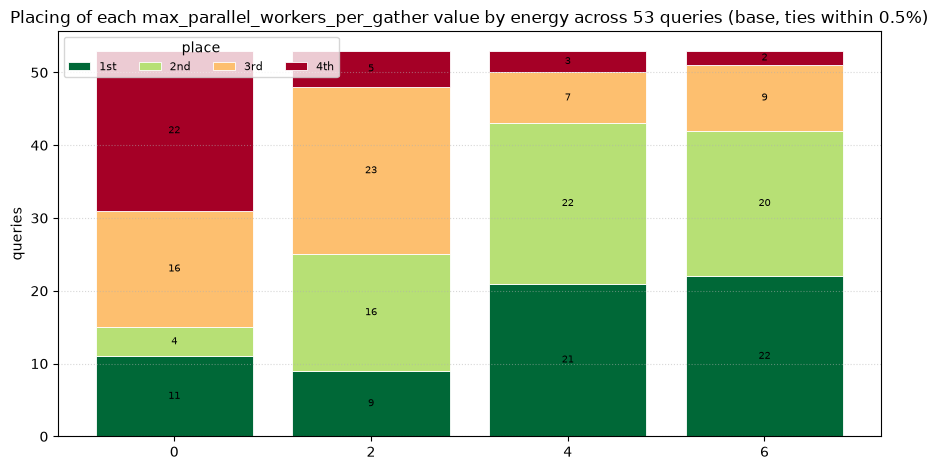

energy placings across 53 queries (ties within 0.5% share a place):
   1st  2nd  3rd  4th
0   11    4   16   22
2    9   16   23    5
4   21   22    7    3
6   22   20    9    2


In [9]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each max_parallel_workers_per_gather value by energy across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("mpw_placing_energy.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"energy placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 7. Indexing vs max_parallel_workers_per_gather — which lever matters more?

Two ways to make a query faster: tune max_parallel_workers_per_gather, or add an index. This compares,
per query, the **max_parallel_workers_per_gather speedup** (base runtime at the smallest vs largest
setting) against the **indexing speedup** (base vs indexed at a fixed, common
setting). Points above the diagonal are helped more by an index; points to the
right are helped more by tuning max_parallel_workers_per_gather.

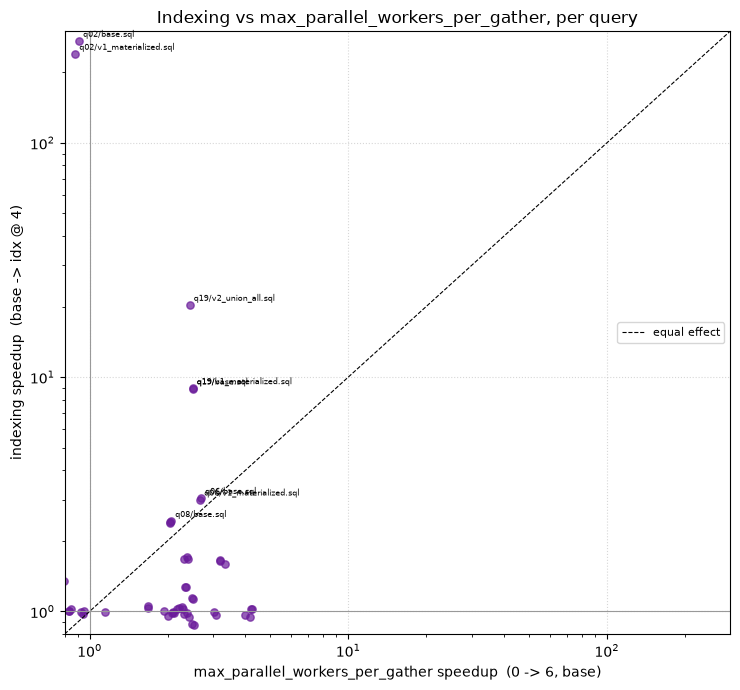

At 4: indexing beats max_parallel_workers_per_gather tuning for 17/53 queries; max_parallel_workers_per_gather wins for 36.


In [10]:
common_pv = [m for m in PVALS
             if {"base", "idx"} <= set(data.loc[data["pval"] == m, "index_status"])]
if not common_pv:
    print("No max_parallel_workers_per_gather value has both base and indexed runs - "
          "cannot compare indexing vs max_parallel_workers_per_gather yet.")
else:
    fix = common_pv[len(common_pv) // 2]           # a middle common value
    base = data[data["index_status"] == "base"]
    rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
    tuning = (rt[PVALS[0]] / rt[PVALS[-1]]).rename("tuning_x")

    bt = data[(data["index_status"] == "base") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    it = data[(data["index_status"] == "idx") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    indexing = (bt / it).rename("indexing_x")

    comp = pd.concat([tuning, indexing], axis=1).dropna()
    comp = comp[(comp["tuning_x"] > 0) & (comp["indexing_x"] > 0)]
    fig, ax = plt.subplots(figsize=(7.5, 7))
    ax.scatter(comp["tuning_x"], comp["indexing_x"], s=28, alpha=0.7, color="#6a1b9a")
    lim = [0.8, max(3.0, comp.to_numpy().max() * 1.1)]
    ax.plot(lim, lim, color="k", lw=0.8, ls="--", label="equal effect")
    ax.axhline(1, color="0.6", lw=0.8); ax.axvline(1, color="0.6", lw=0.8)
    for q, row in comp.sort_values(["indexing_x", "tuning_x"]).tail(8).iterrows():
        ax.annotate(q, (row["tuning_x"], row["indexing_x"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"max_parallel_workers_per_gather speedup  ({p_label(PVALS[0])} -> {p_label(PVALS[-1])}, base)")
    ax.set_ylabel(f"indexing speedup  (base -> idx @ {p_label(fix)})")
    ax.set_title("Indexing vs max_parallel_workers_per_gather, per query")
    ax.legend(fontsize=8); ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    idx_wins = int((comp["indexing_x"] > comp["tuning_x"]).sum())
    print(f"At {p_label(fix)}: indexing beats max_parallel_workers_per_gather tuning for {idx_wins}/{len(comp)} "
          f"queries; max_parallel_workers_per_gather wins for {len(comp) - idx_wins}.")